In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
print(fonts)  # ['NanumGothic', 'NanumBarunGothic', ...] 나오면 정상

Could not save font_manager cache [Errno 2] No such file or directory: '/home/kimkangwook/.cache/matplotlib/fontlist-v3.11.0.json.matplotlib-lock'


## 데이터 합치기

In [1]:
import pandas as pd

df1 = pd.read_csv('data/rent1.csv', encoding='cp949', skiprows=15)
df2 = pd.read_csv('data/rent2.csv', encoding='cp949', skiprows=15)

print('rent1:', df1.shape)
print('rent2:', df2.shape)

df1.head(3)
df2.head(3)

rent1: (540, 18)
rent2: (333, 18)


,NO,시군구,번지,도로조건,계약면적(㎡),전월세구분,계약년월,계약일,보증금(만원),월세금(만원),건축년도,도로명,계약기간,계약구분,갱신요구권 사용,종전계약 보증금(만원),종전계약 월세(만원),주택유형
0,1,인천광역시 미추홀구 용현동,3*,25m이상,23.00,월세,202504,19,300,35,1998.0,인하로,202504~202604,신규,-,NaN,NaN,단독다가구
1,2,인천광역시 미추홀구 용현동,3*,25m이상,42.31,월세,202504,18,500,40,1978.0,인하로,202505~202705,신규,-,NaN,NaN,단독다가구
2,3,인천광역시 미추홀구 용현동,*,12m미만,31.55,월세,202504,18,300,30,1993.0,인하로163번길,202505~202705,신규,-,NaN,NaN,단독다가구


In [2]:
df = pd.concat([df1, df2], ignore_index=True)
print('합친 데이터:', df.shape)
df.head()
df.to_csv('data/rent_merged.csv', index=False, encoding='utf-8-sig')
print('저장 완료: data/rent_merged.csv')

합친 데이터: (873, 18)
저장 완료: data/rent_merged.csv


## 데이터 분석

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
for fname in fm.findSystemFonts():
    try:
        f = fm.FontProperties(fname=fname)
        if any(k in f.get_name() for k in ['Nanum', 'Gothic', 'Malgun', 'AppleGothic']):
            plt.rcParams['font.family'] = f.get_name()
            break
    except:
        pass

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 숫자형 변환 (보증금, 월세 컬럼에 쉼표 제거)
for col in ['보증금(만원)', '월세금(만원)', '종전계약 보증금(만원)', '종전계약 월세(만원)']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '').replace('nan', float('nan'))
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['계약면적(㎡)'] = pd.to_numeric(df['계약면적(㎡)'], errors='coerce')
df['건축년도'] = pd.to_numeric(df['건축년도'], errors='coerce')

TARGET = '월세금(만원)'
print("전처리 완료. 타겟 변수:", TARGET)

## STEP 1: 기본 현황 파악

In [8]:
print(f"샘플 수: {df.shape[0]:,}개  |  변수 수: {df.shape[1]}개")
print(f"\n[컬럼 목록]\n{df.columns.tolist()}")
print("\n[데이터 타입]")
print(df.dtypes)
df.head(3)

샘플 수: 873개  |  변수 수: 18개

[컬럼 목록]
['NO', '시군구', '번지', '도로조건', '계약면적(㎡)', '전월세구분', '계약년월', '계약일', '보증금(만원)', '월세금(만원)', '건축년도', '도로명', '계약기간', '계약구분', '갱신요구권 사용', '종전계약 보증금(만원)', '종전계약 월세(만원)', '주택유형']

[데이터 타입]
NO                int64
시군구                 str
번지                  str
도로조건                str
계약면적(㎡)         float64
전월세구분               str
계약년월              int64
계약일               int64
보증금(만원)           int64
월세금(만원)           int64
건축년도            float64
도로명                 str
계약기간                str
계약구분                str
갱신요구권 사용            str
종전계약 보증금(만원)    float64
종전계약 월세(만원)     float64
주택유형                str
dtype: object


,NO,시군구,번지,도로조건,계약면적(㎡),전월세구분,계약년월,계약일,보증금(만원),월세금(만원),건축년도,도로명,계약기간,계약구분,갱신요구권 사용,종전계약 보증금(만원),종전계약 월세(만원),주택유형
0,1,인천광역시 미추홀구 용현동,5**,25m미만,23.0,월세,202604,11,500,45,2021.0,능해길,202604~202704,신규,-,NaN,NaN,단독다가구
1,2,인천광역시 미추홀구 용현동,4*,8m미만,17.0,월세,202604,6,300,45,NaN,한나루로463번길,202604~202612,신규,-,NaN,NaN,단독다가구
2,3,인천광역시 미추홀구 용현동,6**,8m미만,20.0,월세,202604,4,300,45,2016.0,낙섬서로10번길,202604~202704,신규,-,NaN,NaN,단독다가구


In [7]:
print("[결측치 현황]")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'결측치 수': missing, '결측 비율(%)': missing_pct})
display(missing_df[missing_df['결측치 수'] > 0])

print("\n[기본 통계]")
display(df.describe())

[결측치 현황]


,결측치 수,결측 비율(%)
건축년도,71,8.13
도로명,1,0.11
종전계약 보증금(만원),846,96.91
종전계약 월세(만원),846,96.91



[기본 통계]


,NO,계약면적(㎡),계약년월,계약일,보증금(만원),월세금(만원),건축년도,종전계약 보증금(만원),종전계약 월세(만원)
count,873.000000,873.000000,873.000000,873.000000,873.000000,873.000000,802.000000,27.000000,27.000000
mean,231.020619,28.089507,202506.013746,15.895762,1149.720504,35.780069,2002.630923,5437.074074,12.592593
std,145.283650,11.900230,66.661267,8.640071,2085.035857,16.846779,11.816573,4958.340642,18.731420
min,1.000000,13.000000,202404.000000,1.000000,0.000000,0.000000,1956.000000,276.000000,0.000000
25%,110.000000,20.000000,202501.000000,9.000000,300.000000,30.000000,1996.000000,400.000000,0.000000
50%,219.000000,23.100000,202507.000000,16.000000,300.000000,38.000000,2002.000000,4000.000000,0.000000
75%,328.000000,33.210000,202512.000000,23.000000,500.000000,45.000000,2015.000000,8750.000000,27.000000
max,540.000000,60.000000,202604.000000,31.000000,15900.000000,90.000000,2022.000000,15900.000000,55.000000


## STEP 2: 타겟 변수 및 Feature 분포 시각화

In [ ]:
# 타겟 변수 (월세금) 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[TARGET].dropna(), bins=50, edgecolor='white', color='steelblue')
axes[0].set_title(f'{TARGET} 분포 (원본)')
axes[0].set_xlabel('만원')
axes[0].set_ylabel('빈도')

import numpy as np
log_vals = np.log1p(df[TARGET].dropna())
axes[1].hist(log_vals, bins=50, edgecolor='white', color='salmon')
axes[1].set_title(f'{TARGET} 분포 (로그 변환)')
axes[1].set_xlabel('log(만원 + 1)')

plt.suptitle('타겟 변수 분포', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n월세금 통계:\n{df[TARGET].describe()}")

In [ ]:
# 수치형 feature 분포 (타겟 제외)
num_cols = ['계약면적(㎡)', '보증금(만원)', '건축년도']
fig, axes = plt.subplots(1, len(num_cols), figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(df[col].dropna(), bins=40, edgecolor='white', color='mediumseagreen')
    ax.set_title(col)
    ax.set_ylabel('빈도')
plt.suptitle('수치형 Feature 분포', fontsize=13)
plt.tight_layout()
plt.show()

# 범주형 feature 분포 (상위 10개)
cat_cols = ['전월세구분', '도로조건', '주택유형', '계약구분']
fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts().head(10)
    vc.plot(kind='bar', ax=ax, color='cornflowerblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('범주형 Feature 분포', fontsize=13)
plt.tight_layout()
plt.show()

## STEP 3: Feature와 타겟 변수 간의 관계 분석

In [ ]:
# 수치형 변수 상관관계 히트맵
num_df = df[['보증금(만원)', '월세금(만원)', '계약면적(㎡)', '건축년도', '계약일']].dropna()
corr = num_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('수치형 변수 상관관계 히트맵')
plt.tight_layout()
plt.show()

print("\n타겟(보증금)과의 상관계수:")
print(corr[TARGET].drop(TARGET).sort_values(ascending=False))

In [ ]:
# 수치형 feature vs 타겟 산점도
scatter_cols = ['계약면적(㎡)', '보증금(만원)', '건축년도']
fig, axes = plt.subplots(1, len(scatter_cols), figsize=(15, 4))
for ax, col in zip(axes, scatter_cols):
    ax.scatter(df[col], df[TARGET], alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET)
    ax.set_title(f'{col} vs {TARGET}')
plt.suptitle('수치형 Feature vs 타겟', fontsize=13)
plt.tight_layout()
plt.show()

# 범주형 feature vs 타겟 박스플롯
box_cols = ['전월세구분', '도로조건', '주택유형']
fig, axes = plt.subplots(1, len(box_cols), figsize=(16, 5))
for ax, col in zip(axes, box_cols):
    order = df.groupby(col)[TARGET].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y=TARGET, order=order, ax=ax, palette='Set2')
    ax.set_title(f'{col} vs {TARGET}')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('범주형 Feature vs 타겟 (박스플롯)', fontsize=13)
plt.tight_layout()
plt.show()

## STEP 4: 이상치 탐지

In [ ]:
outlier_cols = ['보증금(만원)', '월세금(만원)', '계약면적(㎡)', '건축년도']

# IQR 방식 이상치 탐지
print("[IQR 기반 이상치 현황]")
outlier_summary = []
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'컬럼': col, 'Q1': q1, 'Q3': q3, '하한': lower, '상한': upper, '이상치 수': n_out, '이상치 비율(%)': round(n_out/len(df)*100, 2)})

display(pd.DataFrame(outlier_summary).set_index('컬럼'))

# 박스플롯
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 5))
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red'))
    ax.set_title(col)
    ax.set_ylabel('값')
plt.suptitle('이상치 박스플롯 (IQR)', fontsize=13)
plt.tight_layout()
plt.show()

## STEP 5: 선형/비선형 특성 판단

In [ ]:
from scipy import stats

linear_cols = ['계약면적(㎡)', '보증금(만원)', '건축년도']

print("[피어슨 상관계수 & Spearman 상관계수 비교]")
print(f"{'Feature':<15} {'Pearson r':>10} {'Spearman r':>12} {'판단':>12}")
print("-" * 52)
results = []
for col in linear_cols:
    sub = df[[col, TARGET]].dropna()
    pearson_r, _ = stats.pearsonr(sub[col], sub[TARGET])
    spearman_r, _ = stats.spearmanr(sub[col], sub[TARGET])
    diff = abs(abs(pearson_r) - abs(spearman_r))
    judgment = "선형" if diff < 0.05 else "비선형"
    results.append({'feature': col, 'pearson': pearson_r, 'spearman': spearman_r, 'judgment': judgment})
    print(f"{col:<15} {pearson_r:>10.3f} {spearman_r:>12.3f} {judgment:>12}")

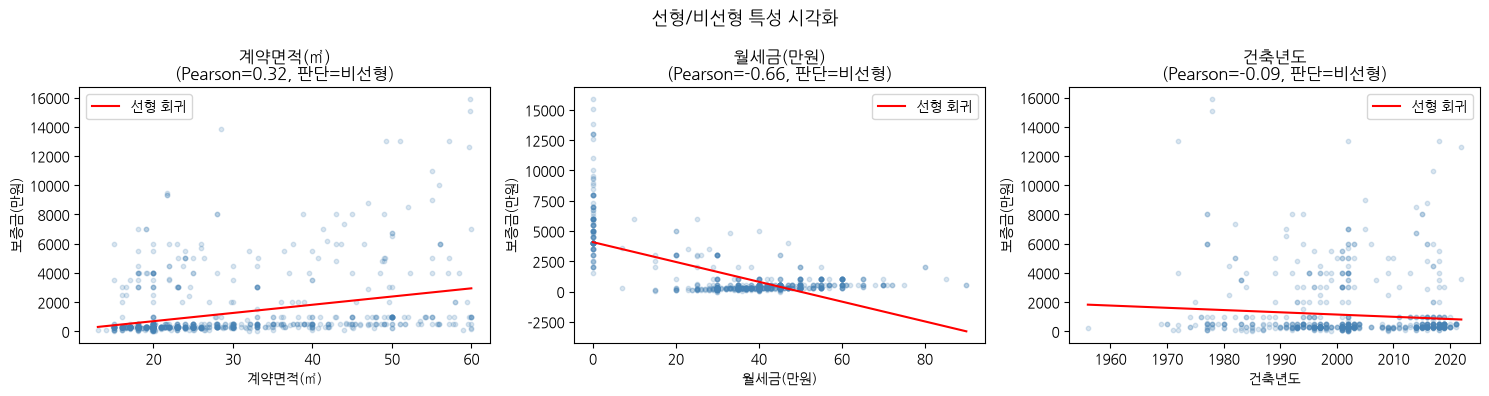


[모델 선택 근거 요약]
비선형 특성 feature: ['계약면적(㎡)', '월세금(만원)', '건축년도']
→ 비선형 모델(Random Forest, XGBoost 등) 또는 feature 변환(로그, 다항) 고려


In [25]:
# 회귀선 포함 산점도 (선형/비선형 시각적 확인)
fig, axes = plt.subplots(1, len(linear_cols), figsize=(15, 4))
for ax, col in zip(axes, linear_cols):
    sub = df[[col, TARGET]].dropna()
    ax.scatter(sub[col], sub[TARGET], alpha=0.2, s=10, color='steelblue')
    # 선형 회귀선
    m, b = np.polyfit(sub[col], sub[TARGET], 1)
    x_line = np.linspace(sub[col].min(), sub[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5, label='선형 회귀')
    r = next(item for item in results if item['feature'] == col)
    ax.set_title(f"{col}\n(Pearson={r['pearson']:.2f}, 판단={r['judgment']})")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET)
    ax.legend()
plt.suptitle('선형/비선형 특성 시각화', fontsize=13)
plt.tight_layout()
plt.show()

print("\n[모델 선택 근거 요약]")
linear_feats = [r['feature'] for r in results if r['judgment'] == '선형']
nonlinear_feats = [r['feature'] for r in results if r['judgment'] == '비선형']
if nonlinear_feats:
    print(f"비선형 특성 feature: {nonlinear_feats}")
    print("→ 비선형 모델(Random Forest, XGBoost 등) 또는 feature 변환(로그, 다항) 고려")
else:
    print(f"전체 feature가 선형 특성 → 선형 회귀 모델 우선 시도 가능")